In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 400

age = np.random.randint(21, 60, N)
monthly_income_inr = np.random.randint(15000, 150000, N)
existing_loans_count = np.random.randint(0, 5, N)
credit_utilization_ratio = np.round(np.random.uniform(0.05, 0.95, N), 2)
upi_monthly_inflow_inr = np.random.randint(2000, 120000, N)
bounced_payments_count = np.random.poisson(1.2, N)
employment_type = np.random.choice(["salaried", "self_employed", "gig"], N,
                                    p=[0.55, 0.30, 0.15])
credit_bureau_score = np.random.randint(300, 900, N).astype(float)

# 20% of applicants are "new to credit" (thin-file): no bureau score at all
thin_file_idx = np.random.choice(N, size=int(0.20 * N), replace=False)
credit_bureau_score[thin_file_idx] = np.nan

# risk score combines income (protective), bounced payments and utilization (risky),
# and UPI inflow (protective, alternate-data signal) -- deliberately usable even
# when credit_bureau_score is missing
z_income = (monthly_income_inr - monthly_income_inr.mean()) / monthly_income_inr.std()
z_bounced = (bounced_payments_count - bounced_payments_count.mean()) / (bounced_payments_count.std() + 1e-9)
z_util = (credit_utilization_ratio - credit_utilization_ratio.mean()) / credit_utilization_ratio.std()
z_upi = (upi_monthly_inflow_inr - upi_monthly_inflow_inr.mean()) / upi_monthly_inflow_inr.std()

risk_score = -2.25 + (-0.9 * z_income) + (0.8 * z_bounced) + (0.7 * z_util) + (-0.5 * z_upi) \
    + np.random.normal(0, 0.6, N)
default_prob = 1 / (1 + np.exp(-risk_score))
default = (np.random.uniform(0, 1, N) < default_prob).astype(int)

df = pd.DataFrame({
    "applicant_id": [f"APP{1000+i}" for i in range(N)],
    "age": age,
    "monthly_income_inr": monthly_income_inr,
    "existing_loans_count": existing_loans_count,
    "credit_utilization_ratio": credit_utilization_ratio,
    "upi_monthly_inflow_inr": upi_monthly_inflow_inr,
    "bounced_payments_count": bounced_payments_count,
    "credit_bureau_score": credit_bureau_score,
    "employment_type": employment_type,
    "default": default,
})
df.to_csv("credit_applicants.csv", index=False)
print(df["default"].value_counts(normalize=True))

# --- second dataset: transaction-behaviour rows for anomaly detection ---
M = 250
behaviour = pd.DataFrame({
    "txn_id": [f"BTXN{5000+i}" for i in range(M)],
    "applicant_id": np.random.choice(df["applicant_id"], M),
    "txn_hour": np.random.randint(6, 23, M),
    "is_new_device": np.random.choice([0, 1], M, p=[0.9, 0.1]),
    "txn_amount_inr": np.random.choice([199, 499, 999, 1999, 3999], M,
                                        p=[0.30, 0.28, 0.22, 0.13, 0.07]),
    "channel": np.random.choice(["P2P", "P2M"], M, p=[0.4, 0.6]),
})
# inject 15 deliberate anomalies: new device, unusual hour (1-4am), high amount
anomalies = pd.DataFrame({
    "txn_id": [f"BTXNA{i}" for i in range(15)],
    "applicant_id": np.random.choice(df["applicant_id"], 15),
    "txn_hour": np.random.randint(1, 5, 15),
    "is_new_device": 1,
    "txn_amount_inr": np.random.choice([14999, 19999, 24999], 15),
    "channel": "P2P",
})
behaviour = pd.concat([behaviour, anomalies], ignore_index=True)  # 265 rows total
behaviour.to_csv("txn_behaviour.csv", index=False)


default
0    0.7975
1    0.2025
Name: proportion, dtype: float64


In [2]:
print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== FIRST 5 ROWS ===")
display(df.head())

=== DATASET SHAPE ===
(400, 10)

=== COLUMNS ===
['applicant_id', 'age', 'monthly_income_inr', 'existing_loans_count', 'credit_utilization_ratio', 'upi_monthly_inflow_inr', 'bounced_payments_count', 'credit_bureau_score', 'employment_type', 'default']

=== FIRST 5 ROWS ===


,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0


In [3]:
default_rate = df["default"].mean() * 100

print("=== DEFAULT RATE ===")
print(f"Default cases: {df['default'].sum()}")
print(f"Total applicants: {len(df)}")
print(f"Default rate: {default_rate:.2f}%")

=== DEFAULT RATE ===
Default cases: 81
Total applicants: 400
Default rate: 20.25%


In [4]:
missing_bureau = df["credit_bureau_score"].isna().sum()
missing_bureau_pct = df["credit_bureau_score"].isna().mean() * 100

print("=== CREDIT BUREAU SCORE ===")
print(f"Missing scores: {missing_bureau}")
print(f"Total applicants: {len(df)}")
print(f"Missing percentage: {missing_bureau_pct:.2f}%")

=== CREDIT BUREAU SCORE ===
Missing scores: 80
Total applicants: 400
Missing percentage: 20.00%


In [5]:
df["is_thin_file"] = df["credit_bureau_score"].isna().astype(int)

print("=== THIN-FILE FLAG ===")
print(df["is_thin_file"].value_counts())

=== THIN-FILE FLAG ===
is_thin_file
0    320
1     80
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("=== TRAIN / TEST SPLIT ===")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training default rate:", f"{y_train.mean() * 100:.2f}%")
print("Test default rate:", f"{y_test.mean() * 100:.2f}%")

=== TRAIN / TEST SPLIT ===
Training rows: 300
Test rows: 100
Training default rate: 20.33%
Test default rate: 20.00%


In [7]:
# Training-only median for credit bureau score
bureau_median = X_train["credit_bureau_score"].median()

X_train["credit_bureau_score"] = X_train["credit_bureau_score"].fillna(bureau_median)
X_test["credit_bureau_score"] = X_test["credit_bureau_score"].fillna(bureau_median)

print("=== MEDIAN IMPUTATION ===")
print(f"Training-derived median: {bureau_median:.2f}")
print("Missing values in training after imputation:",
      X_train["credit_bureau_score"].isna().sum())
print("Missing values in test after imputation:",
      X_test["credit_bureau_score"].isna().sum())

=== MEDIAN IMPUTATION ===
Training-derived median: 612.00
Missing values in training after imputation: 0
Missing values in test after imputation: 0


In [8]:
# One-hot encode employment_type
X_train = pd.get_dummies(X_train, columns=["employment_type"], dtype=int)
X_test = pd.get_dummies(X_test, columns=["employment_type"], dtype=int)

# Ensure train and test have identical columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("=== EMPLOYMENT TYPE ENCODING ===")
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Columns:")
print(X_train.columns.tolist())

=== EMPLOYMENT TYPE ENCODING ===
Training shape: (300, 12)
Test shape: (100, 12)
Columns:
['applicant_id', 'age', 'monthly_income_inr', 'existing_loans_count', 'credit_utilization_ratio', 'upi_monthly_inflow_inr', 'bounced_payments_count', 'credit_bureau_score', 'is_thin_file', 'employment_type_gig', 'employment_type_salaried', 'employment_type_self_employed']


In [9]:
from sklearn.preprocessing import StandardScaler

# Keep applicant_id separate — it is an identifier, not a predictive feature
X_train_model = X_train.drop(columns=["applicant_id"]).copy()
X_test_model = X_test.drop(columns=["applicant_id"]).copy()

# Fit scaler ONLY on training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

print("=== STANDARD SCALING ===")
print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Training mean (approx.):", X_train_scaled.mean(axis=0).round(4))
print("Training std (approx.):", X_train_scaled.std(axis=0).round(4))

=== STANDARD SCALING ===
Training shape: (300, 11)
Test shape: (100, 11)
Training mean (approx.): [ 0.  0. -0.  0. -0. -0.  0.  0.  0.  0. -0.]
Training std (approx.): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("=== LOGISTIC REGRESSION ===")
print("Model trained successfully.")
print("Training accuracy:", logistic_model.score(X_train_scaled, y_train))
print("Test accuracy:", logistic_model.score(X_test_scaled, y_test))

=== LOGISTIC REGRESSION ===
Model trained successfully.
Training accuracy: 0.8433333333333334
Test accuracy: 0.76


In [11]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_scaled, y_train)

print("=== DECISION TREE ===")
print("Model trained successfully.")
print("Training accuracy:", tree_model.score(X_train_scaled, y_train))
print("Test accuracy:", tree_model.score(X_test_scaled, y_test))

=== DECISION TREE ===
Model trained successfully.
Training accuracy: 1.0
Test accuracy: 0.67


In [12]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
lr_pred = logistic_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test_scaled)

# Predicted probabilities for ROC-AUC
lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
tree_prob = tree_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, tree_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, tree_prob)
    ]
})

print("=== LOGISTIC REGRESSION CONFUSION MATRIX ===")
print(confusion_matrix(y_test, lr_pred))

print("\n=== DECISION TREE CONFUSION MATRIX ===")
print(confusion_matrix(y_test, tree_pred))

print("\n=== MODEL COMPARISON ===")
display(results.round(4))

=== LOGISTIC REGRESSION CONFUSION MATRIX ===
[[69 11]
 [13  7]]

=== DECISION TREE CONFUSION MATRIX ===
[[61 19]
 [14  6]]

=== MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.76,0.3889,0.35,0.3684,0.7188
1,Decision Tree,0.67,0.2400,0.30,0.2667,0.5312


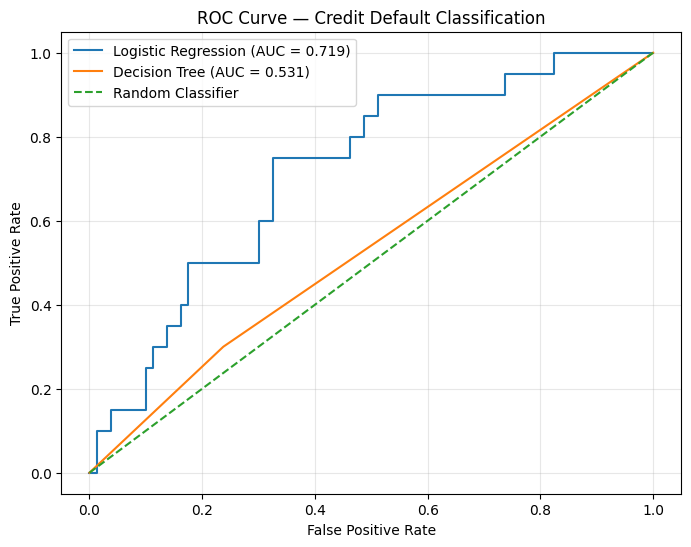

In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, tree_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Default Classification")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
# Risk-based pricing using Logistic Regression probabilities

pricing_df = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_default_probability": lr_prob
})

# Create 4 risk tiers using probability quartiles
pricing_df["risk_tier"] = pd.qcut(
    pricing_df["predicted_default_probability"],
    q=4,
    labels=["Low Risk", "Medium-Low Risk", "Medium-High Risk", "High Risk"]
)

# Calculate observed default rate in each tier
risk_pricing = (
    pricing_df
    .groupby("risk_tier", observed=False)
    .agg(
        applicants=("actual_default", "count"),
        predicted_default_probability=(
            "predicted_default_probability", "mean"
        ),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
risk_pricing["predicted_default_probability"] *= 100
risk_pricing["observed_default_rate"] *= 100

# Illustrative interest-rate ranges
risk_pricing["interest_rate_range"] = [
    "10% - 14%",
    "14% - 18%",
    "18% - 22%",
    "22% - 28%"
]

print("=== RISK-BASED PRICING TABLE ===")
display(risk_pricing.round(2))

=== RISK-BASED PRICING TABLE ===


,risk_tier,applicants,predicted_default_probability,observed_default_rate,interest_rate_range
0,Low Risk,25,2.01,8.0,10% - 14%
1,Medium-Low Risk,25,7.30,12.0,14% - 18%
2,Medium-High Risk,25,23.36,20.0,18% - 22%
3,High Risk,25,58.74,40.0,22% - 28%


In [15]:
# Load transaction behaviour dataset

txn_df = pd.read_csv("txn_behaviour.csv")

print("=== TRANSACTION BEHAVIOUR DATASET ===")
print("Shape:", txn_df.shape)

print("\nColumns:")
print(txn_df.columns.tolist())

print("\nFirst 5 rows:")
display(txn_df.head())

=== TRANSACTION BEHAVIOUR DATASET ===
Shape: (265, 6)

Columns:
['txn_id', 'applicant_id', 'txn_hour', 'is_new_device', 'txn_amount_inr', 'channel']

First 5 rows:


,txn_id,applicant_id,txn_hour,is_new_device,txn_amount_inr,channel
0,BTXN5000,APP1126,15,0,199,P2P
1,BTXN5001,APP1167,22,0,499,P2P
2,BTXN5002,APP1079,18,0,1999,P2P
3,BTXN5003,APP1293,18,1,999,P2M
4,BTXN5004,APP1332,12,0,199,P2P


In [16]:
# Select behavioural features required for anomaly detection

behavior_features = ["txn_hour", "is_new_device", "txn_amount_inr"]

X_anomaly = txn_df[behavior_features]

print("=== ANOMALY DETECTION FEATURES ===")
print("Selected features:", behavior_features)
print("Shape:", X_anomaly.shape)

display(X_anomaly.head())

=== ANOMALY DETECTION FEATURES ===
Selected features: ['txn_hour', 'is_new_device', 'txn_amount_inr']
Shape: (265, 3)


,txn_hour,is_new_device,txn_amount_inr
0,15,0,199
1,22,0,499
2,18,0,1999
3,18,1,999
4,12,0,199


In [17]:
from sklearn.preprocessing import StandardScaler

scaler_anomaly = StandardScaler()

X_anomaly_scaled = scaler_anomaly.fit_transform(X_anomaly)

print("=== STANDARDIZED ANOMALY FEATURES ===")
print("Shape:", X_anomaly_scaled.shape)
print("Mean:", X_anomaly_scaled.mean(axis=0).round(4))
print("Std:", X_anomaly_scaled.std(axis=0).round(4))

=== STANDARDIZED ANOMALY FEATURES ===
Shape: (265, 3)
Mean: [ 0.  0. -0.]
Std: [1. 1. 1.]


In [18]:
from sklearn.ensemble import IsolationForest

# 15 seeded anomalies out of 265 rows
contamination_rate = 15 / 265

iso_forest = IsolationForest(
    random_state=42,
    contamination=contamination_rate
)

iso_predictions = iso_forest.fit_predict(X_anomaly_scaled)

print("=== ISOLATION FOREST ===")
print("Contamination rate:", round(contamination_rate, 4))
print("Expected anomalies:", 15)
print("Predicted anomalies:", (iso_predictions == -1).sum())

=== ISOLATION FOREST ===
Contamination rate: 0.0566
Expected anomalies: 15
Predicted anomalies: 15


In [19]:
# Identify the 15 deliberately injected BTXNA anomalies

true_anomaly = txn_df["txn_id"].str.startswith("BTXNA")

detected_anomaly = iso_predictions == -1

true_positives = (true_anomaly & detected_anomaly).sum()

print("=== ANOMALY RECALL CHECK ===")
print("Seeded anomalies:", true_anomaly.sum())
print("Detected seeded anomalies:", true_positives)
print("Isolation Forest recall:", round(true_positives / true_anomaly.sum(), 4))

=== ANOMALY RECALL CHECK ===
Seeded anomalies: 15
Detected seeded anomalies: 11
Isolation Forest recall: 0.7333


In [20]:
print("=== TASK 6 FINAL RESULT ===")
print(f"Isolation Forest contamination: {contamination_rate:.4f}")
print(f"Seeded anomalies: {true_anomaly.sum()}")
print(f"Detected seeded anomalies: {true_positives}")
print(f"Isolation Forest recall: {true_positives / true_anomaly.sum():.2%}")

=== TASK 6 FINAL RESULT ===
Isolation Forest contamination: 0.0566
Seeded anomalies: 15
Detected seeded anomalies: 11
Isolation Forest recall: 73.33%


In [21]:
from google.colab import files

files.download("credit_applicants.csv")
files.download("txn_behaviour.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>